# Enzyme kinetics

In this notebook we build a few classic rate laws in [basiCO](https://basico.readthedocs.io/en/latest/index.html) (a Python interface to [COPASI](https://copasi.org/)) and see how they behave:

1. **Irreversible Michaelis&ndash;Menten kinetics** - the textbook saturation curve
2. **Reversible Michaelis&ndash;Menten kinetics** - what happens when the product can turn back into substrate
3. **Substrate inhibition** - what happens when *too much* substrate slows the reaction down

We finish with an exercise where you build a more mechanistic model from scratch and compare deterministic and stochastic simulations.

**Learning objectives** - by the end of this notebook you should be able to:
- Assign a kinetic rate law to a reaction in basiCO and map its parameters to named quantities
- Extract the **initial rate** $v_0$ of a reaction directly from a simulation, without needing to run it to steady state
- Recognize how reversibility and substrate inhibition change the shape of the classic $v_0$ vs. $[S]$ curve
- Build a mechanistic (multi-step) enzyme model and compare deterministic vs. stochastic simulations

In [1]:
from basico import *
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Irreversible Michaelis&ndash;Menten kinetics

The simplest and most widely used enzyme rate law:

$$v = \frac{V_{max}\,[S]}{K_m + [S]}$$

- $V_{max}$ is the maximum rate, reached once the enzyme is fully saturated with substrate.
- $K_m$ is the substrate concentration at which the rate is half of $V_{max}$ &mdash; a rough measure of how tightly the enzyme binds its substrate (a *low* $K_m$ means high affinity).

We'll build the reaction $S \rightarrow P$ and assign it this rate law.

In [2]:
new_model(name='Irreversible model')
add_reaction('R1', 'S -> P');

Set the initial concentrations and the kinetic parameters:

In [3]:
vmax = 1
km = 1
initial_S = 1
initial_P = 0

set_species('S', initial_concentration=initial_S)
set_species('P', initial_concentration=initial_P)

add_parameter('vmax', initial_value=vmax)
add_parameter('km', initial_value=km);

COPASI ships a library of predefined rate laws. Let's see which irreversible ones are available:

In [4]:
get_functions(reversible=False)

,reversible,formula,general,mapping
name,,,,
Allosteric inhibition (MWC),False,V*(substrate/Ks)*(1+(substrate/Ks))^(n-1)/(L*(...,False,"{'substrate': 'substrate', 'Inhibitor': 'modif..."
Catalytic activation (irrev),False,V*substrate*Activator/((Kms+substrate)*(Ka+Act...,False,"{'substrate': 'substrate', 'Activator': 'modif..."
Competitive inhibition (irr),False,V*substrate/(Km+substrate+Km*Inhibitor/Ki),False,"{'substrate': 'substrate', 'Inhibitor': 'modif..."
Constant flux (irreversible),False,v,False,{'v': 'parameter'}
Henri-Michaelis-Menten (irreversible),False,V*substrate/(Km+substrate),False,"{'substrate': 'substrate', 'Km': 'parameter', ..."
Hill Cooperativity,False,V*(substrate/Shalve)^h/(1+(substrate/Shalve)^h),False,"{'substrate': 'substrate', 'Shalve': 'paramete..."
Hyperbolic modifier (irrev),False,V*substrate*(1+b*Modifier/(a*Kd))/(Km*(1+Modif...,False,"{'substrate': 'substrate', 'Modifier': 'modifi..."
Mass action (irreversible),False,k1*PRODUCT<substrate_i>,False,"{'k1': 'parameter', 'substrate': 'substrate'}"
Mixed activation (irrev),False,V*substrate*Activator/(Kms*(Kas+Activator)+sub...,False,"{'substrate': 'substrate', 'Activator': 'modif..."


We pick the Henri&ndash;Michaelis&ndash;Menten rate law and map its `Km` and `V` parameters to our named `km` and `vmax` quantities, so we can refer to them by name later on.

In [5]:
set_reaction('R1', function='Henri-Michaelis-Menten (irreversible)')
get_reaction_parameters()

,value,reaction,type,mapped_to
name,,,,
(R1).Km,0.1,R1,local,
(R1).V,0.1,R1,local,


In [6]:
set_reaction_parameters('(R1).Km', mapped_to='km')
set_reaction_parameters('(R1).V', mapped_to='vmax')

### A single time course

Let's simulate the reaction and watch the substrate get converted into product.

In [7]:
result = run_time_course(duration=10, method='deterministic')

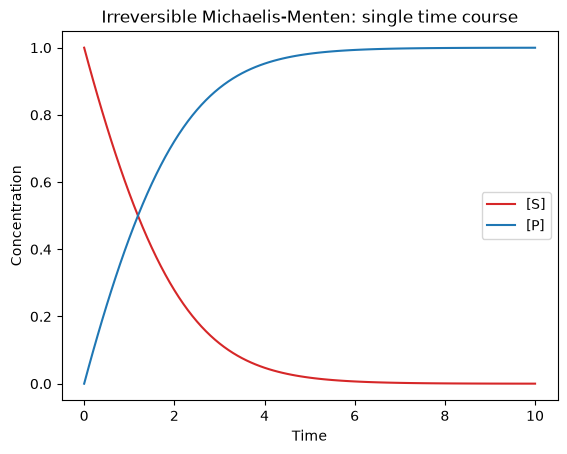

In [8]:
fig, ax = plt.subplots()
result.plot(y='S', color='tab:red', ax=ax, label='[S]')
result.plot(y='P', color='tab:blue', ax=ax, label='[P]')

ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Irreversible Michaelis-Menten: single time course')
ax.legend()

### Effect of the initial substrate concentration

How does the *initial* rate of the reaction depend on how much substrate we start with? Let's overlay several time courses, each starting from a different $[S]_0$.

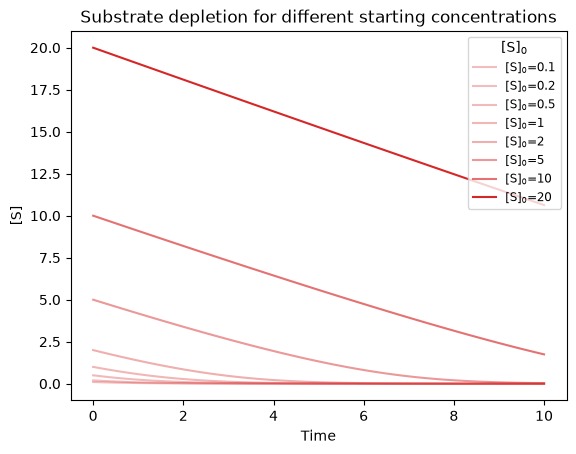

In [9]:
s_values = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20]

fig, ax = plt.subplots()
for s0 in s_values:
    set_species('S', initial_concentration=s0)
    result = run_time_course(duration=10, method='deterministic')
    ax.plot(result.index, result['S'], color='tab:red', alpha=0.3 + 0.7 * s0 / max(s_values),
            label=f'[S]$_0$={s0}')

set_species('S', initial_concentration=initial_S)  # restore original value

ax.set_xlabel('Time')
ax.set_ylabel('[S]')
ax.set_title('Substrate depletion for different starting concentrations')
ax.legend(title='[S]$_0$', fontsize='small')

When determining Michaelis&ndash;Menten parameters in the lab, we typically run the reaction at several initial substrate concentrations and measure the **initial reaction rate** $v_0$ &mdash; for example using a fluorescent reporter. Graphically, $v_0$ is the slope of the curve above at $t=0$.

`run_time_course` only returns concentrations, not rates &mdash; but basiCO can report *any* model quantity through `run_time_course_with_output`, including a reaction's flux. Requesting the flux at $t=0$ gives us $v_0$ directly, with no need to estimate a slope or run the model to steady state.

In [10]:
v0_values = []

for s0 in s_values:
    set_species('S', initial_concentration=s0)
    result = run_time_course_with_output(['Time', '(R1).Flux'],
                                         duration=10)
    v0_values.append(result['(R1).Flux'].iloc[0])  # flux at Time=0 is the initial rate

set_species('S', initial_concentration=initial_S)  # restore original value

mm_data = pd.DataFrame({'S': s_values, 'v0': v0_values})
mm_data

,S,v0
0,0.1,0.090909
1,0.2,0.166667
2,0.5,0.333333
3,1.0,0.500000
4,2.0,0.666667
5,5.0,0.833333
6,10.0,0.909091
7,20.0,0.952381


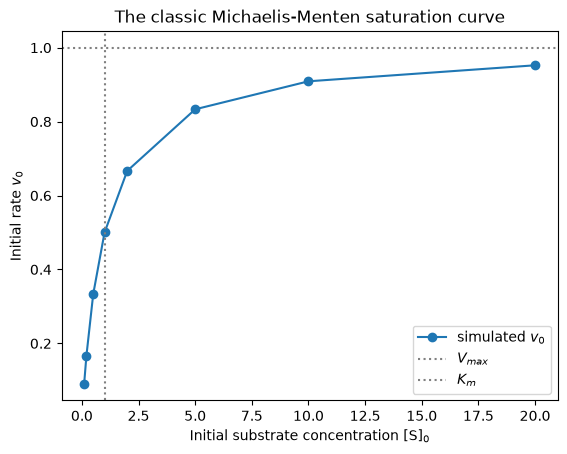

In [11]:
fig, ax = plt.subplots()
ax.plot(mm_data['S'], mm_data['v0'], 'o-', color='tab:blue', label='simulated $v_0$')

ax.axhline(vmax, color='grey', linestyle=':', label='$V_{max}$')
ax.axvline(km, color='grey', linestyle=':', label='$K_m$')

ax.set_xlabel('Initial substrate concentration [S]$_0$')
ax.set_ylabel('Initial rate $v_0$')
ax.set_title('The classic Michaelis-Menten saturation curve')
ax.legend()

As expected, $v_0$ rises steeply at low $[S]$, then saturates towards $V_{max}$. Note that $v_0(K_m) = V_{max}/2$ by definition &mdash; a useful sanity check for your own models.

## 2. Reversible Michaelis&ndash;Menten kinetics

Real reactions can run in both directions. The reversible Michaelis&ndash;Menten rate law adds a reverse term:

$$v = \frac{\dfrac{V_f\,[S]}{K_{ms}} - \dfrac{V_r\,[P]}{K_{mp}}}{1 + \dfrac{[S]}{K_{ms}} + \dfrac{[P]}{K_{mp}}}$$

Now the reaction stops not when the substrate is exhausted, but once it reaches **equilibrium**, i.e. once the forward and reverse fluxes cancel out ($v=0$).

In [12]:
new_model(name='Reversible model')
add_reaction('R1', 'S = P');  # note the '=' : this reaction is reversible

In [13]:
initial_S = 1
initial_P = 0

set_species('S', initial_concentration=initial_S)
set_species('P', initial_concentration=initial_P)

In [14]:
set_reaction('R1', function='Reversible Michaelis-Menten')
get_reaction_parameters()

,value,reaction,type,mapped_to
name,,,,
(R1).Kms,0.1,R1,local,
(R1).Kmp,0.1,R1,local,
(R1).Vf,0.1,R1,local,
(R1).Vr,0.1,R1,local,


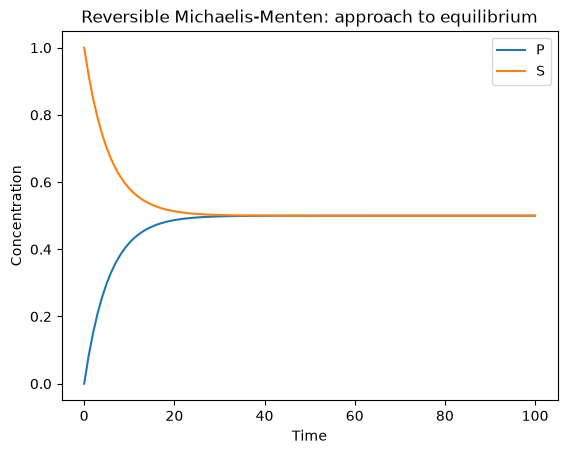

In [15]:
result = run_time_course(duration=100, method='deterministic')

ax = result.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Reversible Michaelis-Menten: approach to equilibrium');

Notice that the substrate never runs out completely &mdash; the reaction reaches an equilibrium rather than going to completion. Where that equilibrium lies depends on the parameters $V_f$, $V_r$, $K_{ms}$, $K_{mp}$: with the default (symmetric) parameter values used here, the equilibrium is at $[S] = [P]$. Try changing $V_r$ or $K_{mp}$ and re-running the cell above to see the equilibrium shift.

## 3. Substrate inhibition

Some enzymes are actually *slowed down* by excess substrate &mdash; typically because a second substrate molecule can bind unproductively and block the active site. This is captured by adding an inhibition term to the denominator:

$$v = \frac{V_{max}\,[S]}{K_m + [S]\left(1 + \dfrac{[S]}{K_i}\right)}$$

Unlike ordinary Michaelis&ndash;Menten kinetics, here $v_0$ doesn't just saturate &mdash; it rises, peaks, and then **decreases** again at high $[S]$, because the $[S]/K_i$ term in the denominator starts to dominate.

In [16]:
new_model(name='Model with substrate inhibition')
add_reaction('R1', 'S -> P');

In [17]:
set_reaction('R1', function='Substrate inhibition (irr)')
get_reaction_parameters()

,value,reaction,type,mapped_to
name,,,,
(R1).Km,0.1,R1,local,
(R1).V,0.1,R1,local,
(R1).Ki,0.1,R1,local,


In [18]:
vmax = 1
km = 1
ki = 1
initial_S = 1
initial_P = 0

set_species('S', initial_concentration=initial_S)
set_species('P', initial_concentration=initial_P)

add_parameter('vmax', initial_value=vmax)
add_parameter('km', initial_value=km)
add_parameter('ki', initial_value=ki)

set_reaction_parameters('(R1).Km', mapped_to='km')
set_reaction_parameters('(R1).V', mapped_to='vmax')
set_reaction_parameters('(R1).Ki', mapped_to='ki')

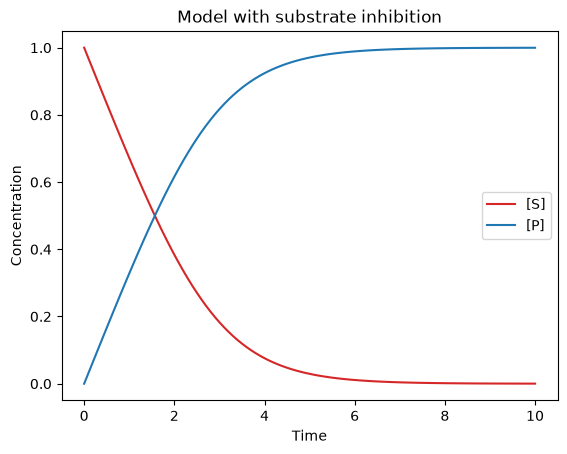

In [19]:
result = run_time_course(duration=10, method='deterministic')

fig, ax = plt.subplots()
result.plot(y='S', color='tab:red', ax=ax, label='[S]')
result.plot(y='P', color='tab:blue', ax=ax, label='[P]')

ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Model with substrate inhibition')
ax.legend()

Let's look at the reaction flux over time for a few different starting concentrations:

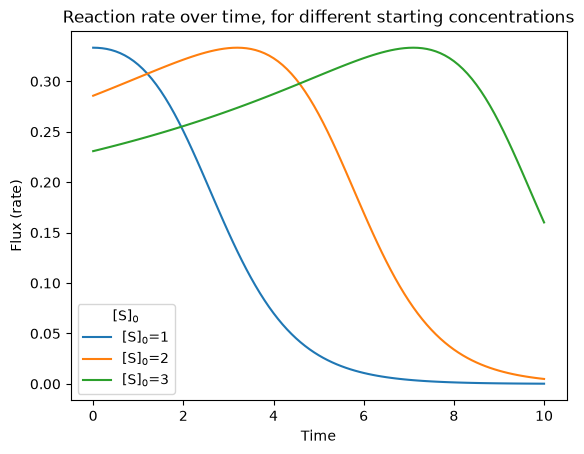

In [20]:
s_values = [1, 2, 3]

fig, ax = plt.subplots()
for s0 in s_values:
    set_species('S', initial_concentration=s0)
    result = run_time_course_with_output(['Time', '(R1).Flux'], duration=10)
    ax.plot(result['Time'], result['(R1).Flux'], label=f'[S]$_0$={s0}')

set_species('S', initial_concentration=initial_S)  # restore original value

ax.set_xlabel('Time')
ax.set_ylabel('Flux (rate)')
ax.set_title('Reaction rate over time, for different starting concentrations')
ax.legend(title='[S]$_0$')

### The substrate-inhibition curve

Just like we did for the irreversible model, we can extract the initial rate $v_0$ for a range of starting concentrations and plot $v_0$ vs. $[S]_0$. This time we should see the rate rise and then *fall* at high $[S]$ &mdash; the signature of substrate inhibition.

Text(0.5, 1.0, 'Substrate inhibition: v0 rises then falls at high [S]')

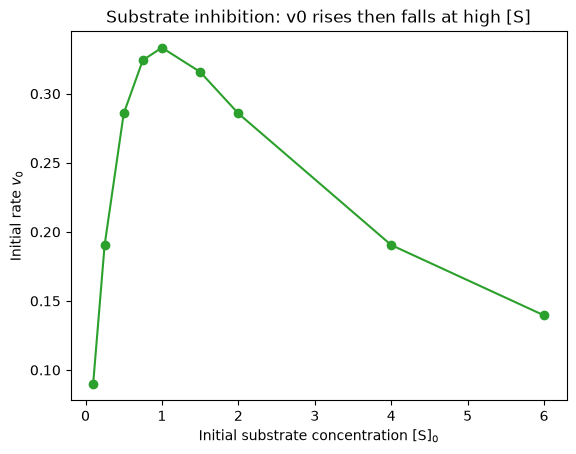

In [21]:
s_values = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 4, 6]
v0_values = []

for s0 in s_values:
    set_species('S', initial_concentration=s0)
    result = run_time_course_with_output(['Time', '(R1).Flux'], duration=10)
    v0_values.append(result['(R1).Flux'].iloc[0])

set_species('S', initial_concentration=initial_S)  # restore original value

si_data = pd.DataFrame({'S': s_values, 'v0': v0_values})

fig, ax = plt.subplots()
ax.plot(si_data['S'], si_data['v0'], 'o-', color='tab:green')
ax.set_xlabel('Initial substrate concentration [S]$_0$')
ax.set_ylabel('Initial rate $v_0$')
ax.set_title('Substrate inhibition: v0 rises then falls at high [S]')

Compare this to the irreversible Michaelis-Menten curve from Section 1: instead of saturating at $V_{max}$, the rate peaks at some intermediate $[S]$ and declines beyond it. The optimal substrate concentration for maximum rate is $[S]_{opt} = \sqrt{K_m K_i}$ &mdash; try checking this against the peak of the curve above.

## Exercise: deterministic vs. stochastic simulation

It is often said that a **deterministic** simulation of a chemical reaction network gives the *average* behavior of the system, and that this is a good representation only when the number of molecules involved is large. When the numbers are small, random fluctuations matter, and **stochastic** simulation is more appropriate.

### Task

Simulate an enzyme-catalyzed reaction (irreversible), where the enzyme can be **deactivated by homodimerization**: two free enzyme molecules can bind to form an inactive dimer, and that dimer is then degraded, while the active (monomeric) enzyme itself is stable.

Use COPASI/basiCO to simulate this reaction network, for a range of parameter settings (e.g. different initial concentrations), both **deterministically** and **stochastically**.

Use your simulations to provide (counter-)evidence for the introductory statement above: under what conditions do the deterministic and stochastic simulations agree, and when do they diverge?

### Hints

- To capture the full mechanism, don't collapse this into a single reaction like `S -> P`. Instead, model the individual steps of enzyme kinetics explicitly:

  ```
  E + S = ES        (binding, reversible)
  ES -> E + P       (catalysis)
  ```

  and add the deactivation pathway for the free enzyme:

  ```
  E + E -> E2        (homodimerization)
  E2 -> (degradation of the inactive dimer)
  ```

- Stochastic simulations work with **discrete numbers of molecules**, not concentrations. Change the model's quantity unit from moles to `#` (number) &mdash; see the SIR notebook for how to do this with `set_model_unit`.
- Use *small* initial numbers of enzyme molecules (e.g. single digits to a few tens) &mdash; the effects of stochasticity are most visible when molecule counts are low.
- Since dimerization pairs up molecules two at a time, think about what happens to an *odd* number of free enzyme molecules compared to an *even* number. Could this parity effect show up differently in a stochastic simulation than in a deterministic one?

### What to submit

- Your completed notebook, with the model, deterministic and stochastic simulations, and clearly labeled plots.
- A short write-up (in markdown cells or a separate short PDF) stating your conclusion: does the deterministic simulation approximate the stochastic one well in this system, and how does that depend on the parameters you chose?